
# Causal Analysis of Reporting Delay and Flock Loss

This notebook reframes the project around a causal question:

> What is the estimated effect of reporting delay on outbreak severity, measured as flock loss?

It uses the new `WAHIS-2026-03-31.csv` extract and follows the team recommendations as closely as the data allow:

- treatment = `reporting_lag_days`
- outcome = `flock_loss`, using only `quant_total_1_deaths_killed_slaughtered_total`
- confounders = geography, outbreak setting, species, subtype, flock size, and season/year
- baseline = log-linear regression
- causal upgrade = double machine learning with cross-fitting
- robustness = propensity-score matching, trimmed-outcome sensitivity, and an early-report subsample

Two important caveats are explicit throughout the notebook:

1. this extract appears to keep one observed `reported_on` value per event, so our lag is the earliest report observable in this extract rather than a guaranteed full reporting-history minimum
2. to keep conditions more comparable, the main analysis restricts the sample to Europe, HxNx poultry outbreaks, non-wild records, and poultry-premises settings


In [3]:
from __future__ import annotations

import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings(
    'ignore',
    message='Found unknown categories in columns',
    category=UserWarning,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")



## Design Choices

The primary sample is intentionally narrower than the raw WAHIS file.

- Geography: Europe only, to keep surveillance and reporting institutions more comparable
- Disease slice: `HxNx` subtype rows only, consistent with the avian-influenza framing of the earlier notebook
- Poultry focus: keep non-wild records and poultry-premises settings only
- Flock-loss outcome: use only `quant_total_1_deaths_killed_slaughtered_total`, because later quantity blocks are often missing or inconsistently populated
- Lag quality filter: keep `0 <= reporting_lag_days <= 365`

This notebook does not claim randomized identification. It aims for a stronger observational design than a plain predictive workflow.


In [4]:

EUROPE_COUNTRIES = {
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia',
    'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia',
    'Lithuania', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom'
}
PREMISES_KEEP = {'Farm', 'Backyard', 'Village', 'Other', 'Slaughterhouse'}
USECOLS = [
    'event_id',
    'outbreak_id',
    'country',
    'subtype_disease_name',
    'event_started_on',
    'reported_on',
    'report_number',
    'admin_division',
    'location',
    'latitude',
    'longitude',
    'epi_unit_type',
    'quant_total_1_species_name',
    'quant_total_1_is_wild',
    'quant_total_1_susceptible',
    'quant_total_1_cases',
    'quant_total_1_deaths_killed_slaughtered_total',
]
CANDIDATE_COLUMNS = [
    'country', 'admin_division', 'location', 'latitude', 'longitude', 'epi_unit_type',
    'species', 'subtype', 'susceptible', 'season', 'start_year'
]
SELECTED_CONFOUNDERS = [
    'country', 'latitude', 'longitude', 'epi_unit_type', 'species', 'subtype',
    'susceptible', 'season', 'start_year'
]
NUMERIC_CONFOUNDERS = ['latitude', 'longitude', 'susceptible']
CATEGORICAL_CONFOUNDERS = ['country', 'epi_unit_type', 'species', 'subtype', 'season', 'start_year']


def first_mode(series: pd.Series):
    mode = series.mode(dropna=True)
    if not mode.empty:
        return mode.iat[0]
    non_null = series.dropna()
    return non_null.iat[0] if not non_null.empty else pd.NA


def month_to_season(month: pd.Series) -> pd.Series:
    mapping = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall',
    }
    return month.map(mapping).astype('category')


def pct_from_log_points(value: float) -> float:
    return (math.exp(value) - 1.0) * 100.0


def load_event_level(path: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    raw = pd.read_csv(path, low_memory=False, usecols=USECOLS)
    subtype_clean = raw['subtype_disease_name'].fillna('').astype(str).str.upper().str.strip()
    mask = (
        subtype_clean.str.fullmatch(r'H\d+N\d+')
        & raw['quant_total_1_is_wild'].eq(False)
        & raw['country'].isin(EUROPE_COUNTRIES)
    )
    restricted = raw.loc[mask].copy()
    restricted['subtype_clean'] = subtype_clean.loc[mask]

    for col in ['event_started_on', 'reported_on']:
        restricted[col] = pd.to_datetime(restricted[col], errors='coerce', utc=True)

    event_level = (
        restricted.groupby(['event_id', 'outbreak_id'], dropna=False)
        .agg(
            start_dt=('event_started_on', 'min'),
            reported_dt=('reported_on', 'min'),
            report_number=('report_number', 'min'),
            country=('country', first_mode),
            admin_division=('admin_division', first_mode),
            location=('location', first_mode),
            latitude=('latitude', 'median'),
            longitude=('longitude', 'median'),
            epi_unit_type=('epi_unit_type', first_mode),
            species=('quant_total_1_species_name', first_mode),
            subtype=('subtype_clean', first_mode),
            susceptible=('quant_total_1_susceptible', 'max'),
            cases=('quant_total_1_cases', 'max'),
            flock_loss=('quant_total_1_deaths_killed_slaughtered_total', 'max'),
        )
        .reset_index()
    )
    event_level['reporting_lag_days'] = (event_level['reported_dt'] - event_level['start_dt']).dt.days
    event_level['start_year'] = event_level['start_dt'].dt.year.astype('Int64')
    event_level['start_month'] = event_level['start_dt'].dt.month.astype('Int64')
    event_level['season'] = month_to_season(event_level['start_month'])
    event_level['log_flock_loss'] = np.log1p(event_level['flock_loss'])

    restriction_steps = pd.DataFrame(
        [
            {'step': 'Europe + HxNx + non-wild raw rows', 'rows': len(restricted)},
            {'step': 'Collapsed to event-outbreak level', 'rows': len(event_level)},
            {'step': 'Keep poultry-premises settings', 'rows': int(event_level['epi_unit_type'].isin(PREMISES_KEEP).sum())},
            {'step': 'Keep 0-365 day lag', 'rows': int((event_level['epi_unit_type'].isin(PREMISES_KEEP) & event_level['reporting_lag_days'].between(0, 365, inclusive='both')).sum())},
            {'step': 'Keep non-missing flock loss', 'rows': int((event_level['epi_unit_type'].isin(PREMISES_KEEP) & event_level['reporting_lag_days'].between(0, 365, inclusive='both') & event_level['flock_loss'].notna()).sum())},
        ]
    )

    modeling = event_level.loc[
        event_level['epi_unit_type'].isin(PREMISES_KEEP)
        & event_level['reporting_lag_days'].between(0, 365, inclusive='both')
        & event_level['flock_loss'].notna()
    ].copy()

    country_counts = modeling['country'].value_counts()
    keep_countries = country_counts[country_counts >= 30].index
    modeling = modeling[modeling['country'].isin(keep_countries)].copy()

    sample_notes = pd.DataFrame(
        [
            {'decision': 'Outcome definition', 'value': 'quant_total_1_deaths_killed_slaughtered_total'},
            {'decision': 'Main treatment window', 'value': '0 to 365 days'},
            {'decision': 'Main geography', 'value': 'Europe only'},
            {'decision': 'Disease filter', 'value': 'HxNx only'},
            {'decision': 'Setting filter', 'value': ', '.join(sorted(PREMISES_KEEP))},
            {'decision': 'Minimum country sample kept', 'value': '30 event-outbreak rows'},
        ]
    )
    return restricted, event_level, restriction_steps, modeling, sample_notes


def build_feature_audit(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for column in CANDIDATE_COLUMNS:
        missing_share = float(df[column].isna().mean())
        selected = column in SELECTED_CONFOUNDERS and missing_share <= 0.40
        if missing_share > 0.40:
            reason = 'Dropped for >40% missingness'
        elif column in SELECTED_CONFOUNDERS:
            reason = 'Selected confounder'
        else:
            reason = 'Available but excluded for parsimony / high cardinality'
        rows.append(
            {
                'column': column,
                'missing_share': missing_share,
                'selected_for_model': selected,
                'reason': reason,
            }
        )
    return pd.DataFrame(rows).sort_values(['selected_for_model', 'missing_share'], ascending=[False, True]).reset_index(drop=True)


def make_preprocessors(drop_first: bool = True):
    cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first' if drop_first else None)
    ols_preprocessor = ColumnTransformer(
        [
            ('lag', Pipeline([('imputer', SimpleImputer(strategy='median'))]), ['reporting_lag_days']),
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), NUMERIC_CONFOUNDERS),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', cat_encoder)]), CATEGORICAL_CONFOUNDERS),
        ],
        remainder='drop',
    )
    nuisance_preprocessor = ColumnTransformer(
        [
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), NUMERIC_CONFOUNDERS),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', cat_encoder)]), CATEGORICAL_CONFOUNDERS),
        ],
        remainder='drop',
    )
    return ols_preprocessor, nuisance_preprocessor


def ols_hc1(X: np.ndarray, y: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.column_stack([np.ones(len(X)), X])
    XtX_inv = np.linalg.pinv(design.T @ design)
    beta = XtX_inv @ (design.T @ y)
    resid = y - design @ beta
    n, p = design.shape
    meat = np.zeros((p, p))
    for i in range(n):
        xi = design[i:i+1].T
        meat += (resid[i] ** 2) * (xi @ xi.T)
    cov = (n / max(n - p, 1)) * XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.diag(cov))
    t_stats = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se > 0)
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=max(n - p, 1)))
    ci_low = beta - stats.t.ppf(0.975, df=max(n - p, 1)) * se
    ci_high = beta + stats.t.ppf(0.975, df=max(n - p, 1)) * se
    return pd.DataFrame(
        {
            'term': ['intercept'] + feature_names,
            'coefficient': beta,
            'std_error_hc1': se,
            't_stat': t_stats,
            'p_value': p_values,
            'ci_95_low': ci_low,
            'ci_95_high': ci_high,
        }
    )


def run_baseline_ols(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ols_preprocessor, _ = make_preprocessors(drop_first=True)
    X = df[['reporting_lag_days'] + SELECTED_CONFOUNDERS].copy()
    y = df['log_flock_loss'].to_numpy(dtype=float)
    X_transformed = ols_preprocessor.fit_transform(X)
    feature_names = ols_preprocessor.get_feature_names_out().tolist()
    result_table = ols_hc1(X_transformed, y, feature_names)
    lag_row = result_table.loc[result_table['term'] == 'lag__reporting_lag_days'].copy()
    lag_row['percent_change_per_day'] = lag_row['coefficient'].map(pct_from_log_points)
    lag_row['percent_change_ci_low'] = lag_row['ci_95_low'].map(pct_from_log_points)
    lag_row['percent_change_ci_high'] = lag_row['ci_95_high'].map(pct_from_log_points)
    return result_table, lag_row


def run_dml(df: pd.DataFrame, n_splits: int = 5, random_state: int = 42) -> tuple[pd.DataFrame, pd.DataFrame]:
    _, nuisance_preprocessor = make_preprocessors(drop_first=True)
    W = df[SELECTED_CONFOUNDERS].copy()
    T = df['reporting_lag_days'].to_numpy(dtype=float)
    Y = df['log_flock_loss'].to_numpy(dtype=float)
    T_hat = np.zeros(len(df))
    Y_hat = np.zeros(len(df))
    folds = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, test_idx in folds.split(W):
        W_train = nuisance_preprocessor.fit_transform(W.iloc[train_idx])
        W_test = nuisance_preprocessor.transform(W.iloc[test_idx])
        model_t = HistGradientBoostingRegressor(max_depth=6, max_iter=250, learning_rate=0.05, random_state=random_state)
        model_y = HistGradientBoostingRegressor(max_depth=6, max_iter=250, learning_rate=0.05, random_state=random_state + 1)
        model_t.fit(W_train, T[train_idx])
        model_y.fit(W_train, Y[train_idx])
        T_hat[test_idx] = model_t.predict(W_test)
        Y_hat[test_idx] = model_y.predict(W_test)

    residual_df = pd.DataFrame(
        {
            'treatment_residual': T - T_hat,
            'outcome_residual': Y - Y_hat,
        },
        index=df.index,
    )
    result_table = ols_hc1(residual_df[['treatment_residual']].to_numpy(), residual_df['outcome_residual'].to_numpy(), ['treatment_residual'])
    focal = result_table.loc[result_table['term'] == 'treatment_residual'].copy()
    focal['percent_change_per_day'] = focal['coefficient'].map(pct_from_log_points)
    focal['percent_change_ci_low'] = focal['ci_95_low'].map(pct_from_log_points)
    focal['percent_change_ci_high'] = focal['ci_95_high'].map(pct_from_log_points)
    return result_table, residual_df, focal


def run_matching(df: pd.DataFrame, threshold: float | None = None, caliper: float = 0.05) -> tuple[pd.DataFrame, pd.DataFrame]:
    _, nuisance_preprocessor = make_preprocessors(drop_first=True)
    W = df[SELECTED_CONFOUNDERS].copy()
    X_match = nuisance_preprocessor.fit_transform(W)
    T = df['reporting_lag_days'].to_numpy(dtype=float)
    Y = df['log_flock_loss'].to_numpy(dtype=float)
    if threshold is None:
        threshold = float(np.median(T))
    treated = (T > threshold).astype(int)

    propensity_model = LogisticRegression(max_iter=2000)
    propensity_model.fit(X_match, treated)
    propensity = propensity_model.predict_proba(X_match)[:, 1]

    treated_idx = np.where(treated == 1)[0]
    control_idx = np.where(treated == 0)[0]
    matcher = NearestNeighbors(n_neighbors=1)
    matcher.fit(propensity[control_idx].reshape(-1, 1))
    distances, matched_positions = matcher.kneighbors(propensity[treated_idx].reshape(-1, 1))
    matched_mask = distances[:, 0] <= caliper
    matched_treated = treated_idx[matched_mask]
    matched_controls = control_idx[matched_positions[:, 0][matched_mask]]

    matched_pairs = pd.DataFrame(
        {
            'treated_index': matched_treated,
            'control_index': matched_controls,
            'treated_lag': T[matched_treated],
            'control_lag': T[matched_controls],
            'treated_log_loss': Y[matched_treated],
            'control_log_loss': Y[matched_controls],
            'pair_effect_log_points': Y[matched_treated] - Y[matched_controls],
            'treated_propensity': propensity[matched_treated],
            'control_propensity': propensity[matched_controls],
        }
    )

    if matched_pairs.empty:
        summary = pd.DataFrame([{'metric': 'matched_pairs', 'value': 0.0}])
        return summary, matched_pairs

    effect = matched_pairs['pair_effect_log_points'].mean()
    se = matched_pairs['pair_effect_log_points'].std(ddof=1) / math.sqrt(len(matched_pairs))
    t_stat = effect / se if se > 0 else np.nan
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=max(len(matched_pairs) - 1, 1))) if se > 0 else np.nan
    ci_half = stats.t.ppf(0.975, df=max(len(matched_pairs) - 1, 1)) * se if se > 0 else np.nan
    summary = pd.DataFrame(
        [
            {'metric': 'matched_pairs', 'value': float(len(matched_pairs))},
            {'metric': 'high_lag_threshold_days', 'value': float(threshold)},
            {'metric': 'att_log_points', 'value': float(effect)},
            {'metric': 'att_std_error', 'value': float(se)},
            {'metric': 'att_p_value', 'value': float(p_value)},
            {'metric': 'att_percent_difference', 'value': float(pct_from_log_points(effect))},
            {'metric': 'att_percent_ci_low', 'value': float(pct_from_log_points(effect - ci_half)) if se > 0 else np.nan},
            {'metric': 'att_percent_ci_high', 'value': float(pct_from_log_points(effect + ci_half)) if se > 0 else np.nan},
        ]
    )
    return summary, matched_pairs


In [5]:

restricted_rows, event_level, restriction_steps, modeling_df, sample_notes = load_event_level('WAHIS-2026-03-31.csv')

dataset_overview = pd.DataFrame(
    [
        {'table': 'Restricted raw rows', 'rows': len(restricted_rows), 'columns': restricted_rows.shape[1]},
        {'table': 'Event-outbreak table', 'rows': len(event_level), 'columns': event_level.shape[1]},
        {'table': 'Primary modeling sample', 'rows': len(modeling_df), 'columns': modeling_df.shape[1]},
    ]
)

display(Markdown('### Dataset Overview'))
display(dataset_overview)

display(Markdown('### Restriction Steps'))
display(restriction_steps)

display(Markdown('### Analysis Notes'))
display(sample_notes)

display(Markdown('### Primary Sample Head'))
display(
    modeling_df[
        [
            'event_id', 'outbreak_id', 'country', 'epi_unit_type', 'species', 'subtype',
            'start_dt', 'reported_dt', 'report_number', 'reporting_lag_days',
            'susceptible', 'cases', 'flock_loss'
        ]
    ].head(10)
)

country_summary = modeling_df['country'].value_counts().rename_axis('country').reset_index(name='outbreak_rows')
display(Markdown('### Top Countries in the Primary Sample'))
display(country_summary.head(15))


### Dataset Overview

,table,rows,columns
0,Restricted raw rows,13768,18
1,Event-outbreak table,13732,21
2,Primary modeling sample,4988,21


### Restriction Steps

,step,rows
0,Europe + HxNx + non-wild raw rows,13768
1,Collapsed to event-outbreak level,13732
2,Keep poultry-premises settings,11841
3,Keep 0-365 day lag,5104
4,Keep non-missing flock loss,5102


### Analysis Notes

,decision,value
0,Outcome definition,quant_total_1_deaths_killed_slaughtered_total
1,Main treatment window,0 to 365 days
2,Main geography,Europe only
3,Disease filter,HxNx only
4,Setting filter,"Backyard, Farm, Other, Slaughterhouse, Village"
5,Minimum country sample kept,30 event-outbreak rows


### Primary Sample Head

,event_id,outbreak_id,country,epi_unit_type,species,subtype,start_dt,reported_dt,report_number,reporting_lag_days,susceptible,cases,flock_loss
2623,3355,77741.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2624,3355,77963.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2625,3355,78197.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2626,3355,78365.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2627,3355,78619.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2628,3355,78620.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2629,3355,79133.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2630,3355,79134.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2631,3355,80143.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0
2632,3355,82785.0,Netherlands,Farm,Birds,H5N8,2020-10-29 00:00:00+00:00,2021-07-16 11:07:27.686000+00:00,12,260.0,514418.0,23878.0,514418.0


### Top Countries in the Primary Sample

,country,outbreak_rows
0,Hungary,864
1,United Kingdom,838
2,Poland,650
3,Germany,644
4,France,621
5,Italy,487
6,Sweden,280
7,Czech Republic,210
8,Portugal,70
9,Denmark,67


In [6]:

feature_audit = build_feature_audit(modeling_df)

display(Markdown('### Missingness Audit for Candidate Confounders'))
display(feature_audit.style.format({'missing_share': '{:.1%}'}))

selected_feature_table = feature_audit.loc[feature_audit['selected_for_model']].copy()
display(Markdown('### Final Confounder Set Used in the Models'))
display(selected_feature_table[['column', 'missing_share', 'reason']].style.format({'missing_share': '{:.1%}'}))

summary_stats = modeling_df[['reporting_lag_days', 'susceptible', 'flock_loss', 'log_flock_loss']].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).transpose()
display(Markdown('### Core Variable Summary'))
display(summary_stats)


### Missingness Audit for Candidate Confounders

,column,missing_share,selected_for_model,reason
0,country,0.0%,True,Selected confounder
1,latitude,0.0%,True,Selected confounder
2,longitude,0.0%,True,Selected confounder
3,epi_unit_type,0.0%,True,Selected confounder
4,species,0.0%,True,Selected confounder
5,subtype,0.0%,True,Selected confounder
6,season,0.0%,True,Selected confounder
7,start_year,0.0%,True,Selected confounder
8,susceptible,0.0%,True,Selected confounder
9,admin_division,0.0%,False,Available but excluded for parsimony / high cardinality


### Final Confounder Set Used in the Models

,column,missing_share,reason
0,country,0.0%,Selected confounder
1,latitude,0.0%,Selected confounder
2,longitude,0.0%,Selected confounder
3,epi_unit_type,0.0%,Selected confounder
4,species,0.0%,Selected confounder
5,subtype,0.0%,Selected confounder
6,season,0.0%,Selected confounder
7,start_year,0.0%,Selected confounder
8,susceptible,0.0%,Selected confounder


### Core Variable Summary

,count,mean,std,min,5%,25%,50%,75%,95%,max
reporting_lag_days,4988.0,1.937596e+02,7.333852e+01,1.0,78.350000,150.000000,182.00000,2.360000e+02,3.090000e+02,3.570000e+02
susceptible,4987.0,2.022361e+06,3.461690e+06,4.0,152.000000,2255.000000,533883.00000,2.425269e+06,1.380895e+07,1.380895e+07
flock_loss,4988.0,2.017659e+06,3.461685e+06,0.0,152.000000,2049.000000,525538.00000,2.425269e+06,1.380887e+07,1.380887e+07
log_flock_loss,4988.0,1.186653e+01,3.669900e+00,0.0,5.030438,7.625595,13.17218,1.470145e+01,1.644082e+01,1.644082e+01


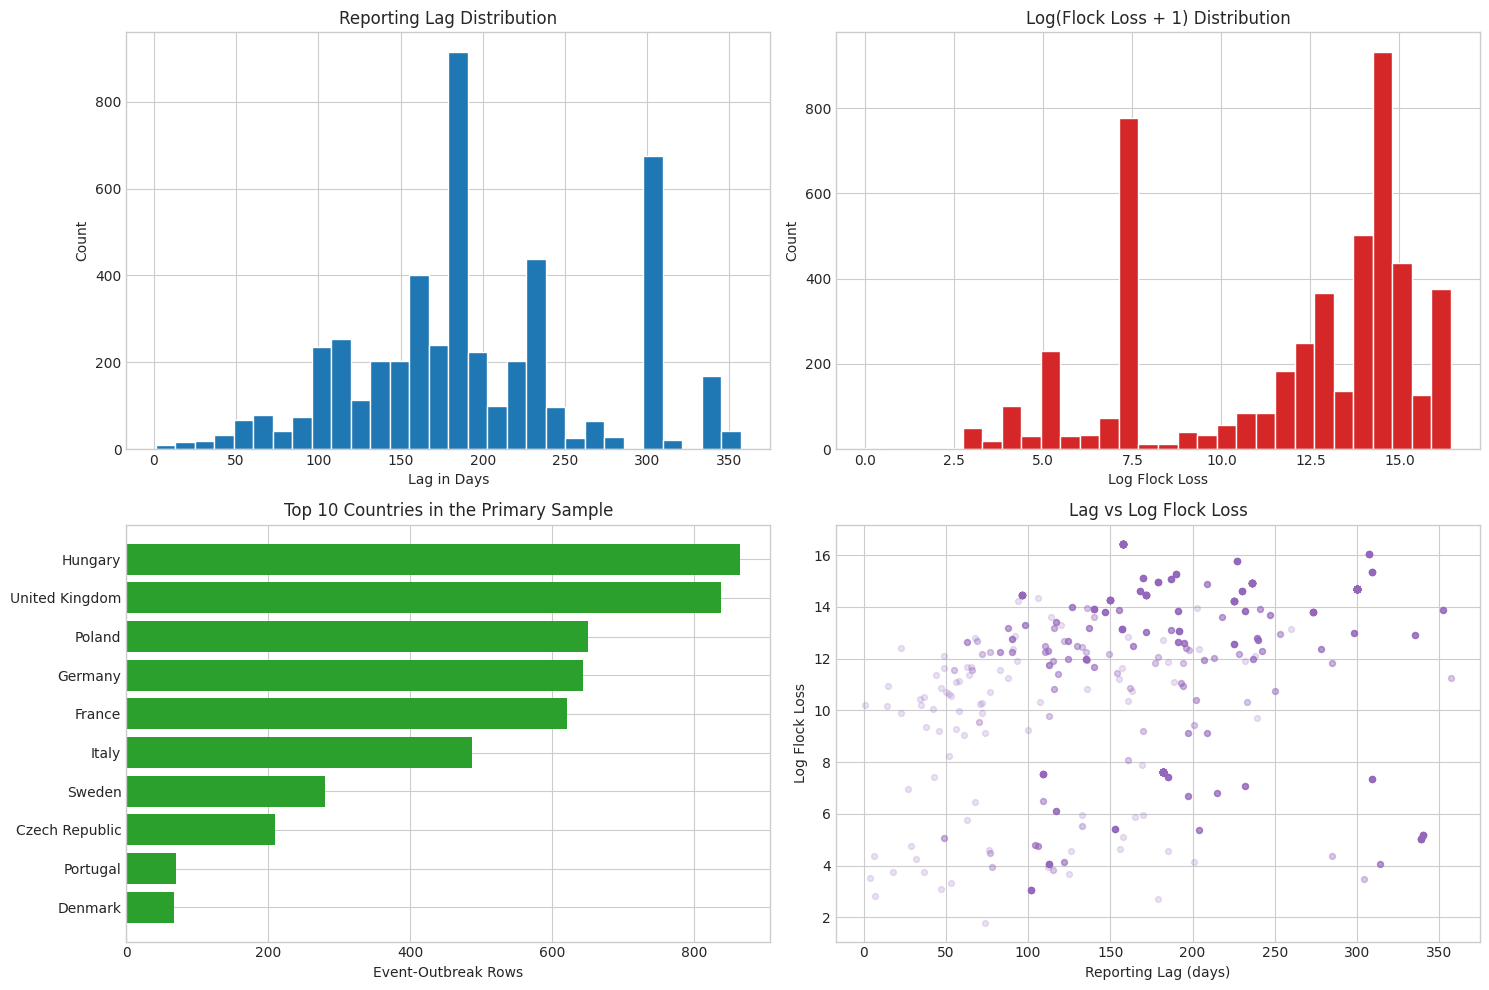

### Country-Level Median Lag and Mean Severity

,country,median_lag,mean_log_loss,outbreaks
6,Hungary,225.0,13.579843,864
14,United Kingdom,182.0,8.476032,838
9,Poland,196.0,13.085144,650
5,Germany,182.0,11.509523,644
4,France,300.0,14.515004,621
7,Italy,158.0,15.719900,487
13,Sweden,339.0,5.199215,280
2,Czech Republic,191.0,9.064932,210
10,Portugal,203.0,7.817374,70
3,Denmark,172.0,11.369630,67


In [7]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(modeling_df['reporting_lag_days'], bins=30, color='#1f77b4', edgecolor='white')
axes[0, 0].set_title('Reporting Lag Distribution')
axes[0, 0].set_xlabel('Lag in Days')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(modeling_df['log_flock_loss'], bins=30, color='#d62728', edgecolor='white')
axes[0, 1].set_title('Log(Flock Loss + 1) Distribution')
axes[0, 1].set_xlabel('Log Flock Loss')
axes[0, 1].set_ylabel('Count')

country_counts = modeling_df['country'].value_counts().head(10).sort_values()
axes[1, 0].barh(country_counts.index, country_counts.values, color='#2ca02c')
axes[1, 0].set_title('Top 10 Countries in the Primary Sample')
axes[1, 0].set_xlabel('Event-Outbreak Rows')

sample_plot = modeling_df.sample(min(len(modeling_df), 1500), random_state=42)
axes[1, 1].scatter(sample_plot['reporting_lag_days'], sample_plot['log_flock_loss'], alpha=0.2, s=18, color='#9467bd')
axes[1, 1].set_title('Lag vs Log Flock Loss')
axes[1, 1].set_xlabel('Reporting Lag (days)')
axes[1, 1].set_ylabel('Log Flock Loss')

plt.tight_layout()
plt.show()

lag_by_country = modeling_df.groupby('country', as_index=False).agg(
    median_lag=('reporting_lag_days', 'median'),
    mean_log_loss=('log_flock_loss', 'mean'),
    outbreaks=('event_id', 'count'),
)
lag_by_country = lag_by_country.sort_values('outbreaks', ascending=False)
display(Markdown('### Country-Level Median Lag and Mean Severity'))
display(lag_by_country.head(15))



## Estimation Strategy

The estimation sequence mirrors the team recommendations.

1. **Baseline log-linear regression**
   - outcome: `log(flock_loss + 1)`
   - focal coefficient: `reporting_lag_days`
   - controls: country fixed effects, lat/long, epi-unit type, species, subtype, susceptible flock size, season, and start year

2. **Double Machine Learning**
   - nuisance model for treatment: `reporting_lag_days ~ X`
   - nuisance model for outcome: `log(flock_loss + 1) ~ X`
   - cross-fitted residual-on-residual regression isolates the treatment effect after flexibly partialling out `X`

3. **Propensity-score matching robustness**
   - define high-delay outbreaks as those above the sample median lag
   - match high-delay outbreaks to low-delay outbreaks with similar confounders

4. **Sensitivity checks**
   - remove the top 5% most extreme flock-loss observations
   - re-estimate on an early-report subsample with `report_number <= 2`


In [8]:

ols_table, ols_lag = run_baseline_ols(modeling_df)

display(Markdown('### Baseline OLS: Focal Lag Coefficient'))
display(ols_lag.style.format({
    'coefficient': '{:.6f}',
    'std_error_hc1': '{:.6f}',
    'p_value': '{:.4g}',
    'ci_95_low': '{:.6f}',
    'ci_95_high': '{:.6f}',
    'percent_change_per_day': '{:.3f}%',
    'percent_change_ci_low': '{:.3f}%',
    'percent_change_ci_high': '{:.3f}%',
}))

display(Markdown('### Baseline OLS: Largest Coefficients by Absolute Value'))
ols_table['abs_coef'] = ols_table['coefficient'].abs()
display(ols_table.sort_values('abs_coef', ascending=False).head(15).drop(columns='abs_coef'))

baseline_beta = float(ols_lag['coefficient'].iloc[0])
baseline_pct = float(ols_lag['percent_change_per_day'].iloc[0])
baseline_p = float(ols_lag['p_value'].iloc[0])

display(Markdown(
    f'**Interpretation.** In the baseline log-linear specification, one additional day of reporting delay is associated with an estimated **{baseline_pct:.3f}%** change in flock loss, with p-value **{baseline_p:.4g}**.'
))


### Baseline OLS: Focal Lag Coefficient

,term,coefficient,std_error_hc1,t_stat,p_value,ci_95_low,ci_95_high,percent_change_per_day,percent_change_ci_low,percent_change_ci_high
1,lag__reporting_lag_days,0.007994,0.000696,11.488840,0,0.006630,0.009358,0.803%,0.665%,0.940%


### Baseline OLS: Largest Coefficients by Absolute Value

,term,coefficient,std_error_hc1,t_stat,p_value,ci_95_low,ci_95_high
0,intercept,8.065425,0.445934,18.086596,0.000000e+00,7.191197,8.939653
23,cat__species_Cats,-5.771917,0.221712,-26.033377,0.000000e+00,-6.206571,-5.337263
24,cat__subtype_H5N2,-4.617335,1.250675,-3.691873,2.250056e-04,-7.069214,-2.165457
20,cat__epi_unit_type_Other,-3.031960,0.203774,-14.879053,0.000000e+00,-3.431447,-2.632473
29,cat__subtype_H7N7,-3.012043,0.199094,-15.128789,0.000000e+00,-3.402355,-2.621732
16,cat__country_Spain,2.891736,0.436100,6.630894,3.692913e-11,2.036786,3.746686
21,cat__epi_unit_type_Slaughterhouse,2.834455,0.946944,2.993267,2.773719e-03,0.978026,4.690885
19,cat__epi_unit_type_Farm,2.802379,0.159096,17.614389,0.000000e+00,2.490481,3.114278
25,cat__subtype_H5N3,-2.748843,0.201987,-13.608985,0.000000e+00,-3.144827,-2.352858
17,cat__country_Sweden,-2.709195,0.355324,-7.624584,2.908784e-14,-3.405787,-2.012603


**Interpretation.** In the baseline log-linear specification, one additional day of reporting delay is associated with an estimated **0.803%** change in flock loss, with p-value **0**.

### Double Machine Learning: Residual-on-Residual Estimate

,term,coefficient,std_error_hc1,t_stat,p_value,ci_95_low,ci_95_high,percent_change_per_day,percent_change_ci_low,percent_change_ci_high
1,treatment_residual,0.002767,0.001896,1.459617,0.1445,-0.000949,0.006483,0.277%,-0.095%,0.650%


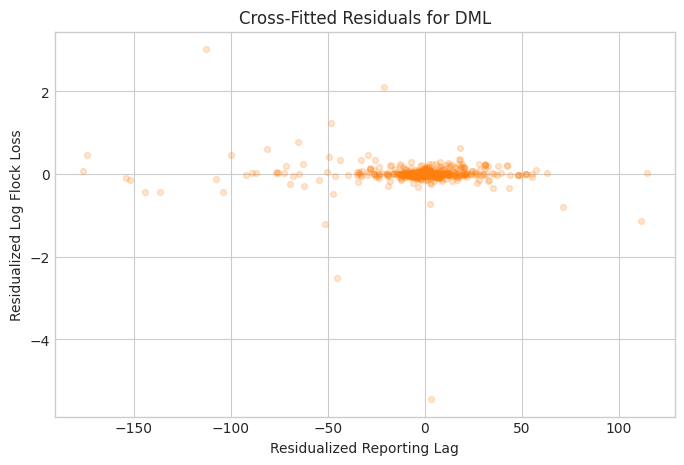

**Interpretation.** After flexible residualization of observed confounders, the DML estimate implies about **0.277%** change in flock loss per additional day of delay, with p-value **0.1445**.

In [9]:

dml_table, dml_residuals, dml_lag = run_dml(modeling_df)

display(Markdown('### Double Machine Learning: Residual-on-Residual Estimate'))
display(dml_lag.style.format({
    'coefficient': '{:.6f}',
    'std_error_hc1': '{:.6f}',
    'p_value': '{:.4g}',
    'ci_95_low': '{:.6f}',
    'ci_95_high': '{:.6f}',
    'percent_change_per_day': '{:.3f}%',
    'percent_change_ci_low': '{:.3f}%',
    'percent_change_ci_high': '{:.3f}%',
}))

fig, ax = plt.subplots(figsize=(8, 5))
resid_sample = dml_residuals.sample(min(len(dml_residuals), 1500), random_state=42)
ax.scatter(resid_sample['treatment_residual'], resid_sample['outcome_residual'], alpha=0.2, s=18, color='#ff7f0e')
ax.set_title('Cross-Fitted Residuals for DML')
ax.set_xlabel('Residualized Reporting Lag')
ax.set_ylabel('Residualized Log Flock Loss')
plt.show()


dml_beta = float(dml_lag['coefficient'].iloc[0])
dml_pct = float(dml_lag['percent_change_per_day'].iloc[0])
dml_p = float(dml_lag['p_value'].iloc[0])

display(Markdown(
    f'**Interpretation.** After flexible residualization of observed confounders, the DML estimate implies about **{dml_pct:.3f}%** change in flock loss per additional day of delay, with p-value **{dml_p:.4g}**.'
))


In [10]:
matching_summary, matched_pairs = run_matching(modeling_df)

display(Markdown('### Propensity-Score Matching Robustness'))
display(matching_summary.style.format({'value': '{:.6f}'}))

if not matched_pairs.empty:
    display(Markdown('### Matched Pair Snapshot'))
    display(matched_pairs.head(10))
    att_log = float(matching_summary.loc[matching_summary['metric'] == 'att_log_points', 'value'].iloc[0])
    att_pct = float(matching_summary.loc[matching_summary['metric'] == 'att_percent_difference', 'value'].iloc[0])
    matched_n = int(matching_summary.loc[matching_summary['metric'] == 'matched_pairs', 'value'].iloc[0])
    display(Markdown(
        f"**Interpretation.** The matching design found **{matched_n:,}** matched pairs. The estimated ATT is **{att_log:.3f} log points**, which exponentiates to **{att_pct:.1f}%**. Because this estimate is much more sensitive to overlap and caliper choice than OLS or DML, it should be treated as a rough robustness check rather than the headline result."
    ))
else:
    display(Markdown('No matched pairs satisfied the caliper, so the matching robustness check was inconclusive.'))


### Propensity-Score Matching Robustness

,metric,value
0,matched_pairs,2256.000000
1,high_lag_threshold_days,182.000000
2,att_log_points,5.337408
3,att_std_error,0.106649
4,att_p_value,0.000000
5,att_percent_difference,20697.301554
6,att_percent_ci_low,16772.466145
7,att_percent_ci_high,25535.123413


### Matched Pair Snapshot

,treated_index,control_index,treated_lag,control_lag,treated_log_loss,control_log_loss,pair_effect_log_points,treated_propensity,control_propensity
0,0,2749,260.0,90.0,13.150793,12.249161,0.901633,0.948502,0.948681
1,1,2749,260.0,90.0,13.150793,12.249161,0.901633,0.948582,0.948681
2,2,2767,260.0,45.0,13.150793,11.417295,1.733498,0.951143,0.951196
3,3,2767,260.0,45.0,13.150793,11.417295,1.733498,0.949951,0.951196
4,4,2749,260.0,90.0,13.150793,12.249161,0.901633,0.949362,0.948681
5,5,2749,260.0,90.0,13.150793,12.249161,0.901633,0.947259,0.948681
6,6,2749,260.0,90.0,13.150793,12.249161,0.901633,0.945895,0.948681
7,7,2749,260.0,90.0,13.150793,12.249161,0.901633,0.949929,0.948681
8,8,2749,260.0,90.0,13.150793,12.249161,0.901633,0.947539,0.948681
9,9,2749,260.0,90.0,13.150793,12.249161,0.901633,0.948075,0.948681


**Interpretation.** The matching design found **2,256** matched pairs. The estimated ATT is **5.337 log points**, which exponentiates to **20697.3%**. Because this estimate is much more sensitive to overlap and caliper choice than OLS or DML, it should be treated as a rough robustness check rather than the headline result.

In [11]:
trimmed_df = modeling_df.loc[modeling_df['flock_loss'].rank(method='first', pct=True) <= 0.95].copy()
early_report_df = modeling_df.loc[modeling_df['report_number'] <= 2].copy()

trim_ols_table, trim_ols_lag = run_baseline_ols(trimmed_df)
robustness_rows = [
    {
        'check': 'Primary OLS',
        'sample_size': len(modeling_df),
        'effect_type': 'Per additional day',
        'estimate_log_points': float(ols_lag['coefficient'].iloc[0]),
        'estimate_percent': float(ols_lag['percent_change_per_day'].iloc[0]),
        'p_value': float(ols_lag['p_value'].iloc[0]),
    },
    {
        'check': 'Primary DML',
        'sample_size': len(modeling_df),
        'effect_type': 'Per additional day',
        'estimate_log_points': float(dml_lag['coefficient'].iloc[0]),
        'estimate_percent': float(dml_lag['percent_change_per_day'].iloc[0]),
        'p_value': float(dml_lag['p_value'].iloc[0]),
    },
    {
        'check': 'Trim top 5% flock loss',
        'sample_size': len(trimmed_df),
        'effect_type': 'Per additional day',
        'estimate_log_points': float(trim_ols_lag['coefficient'].iloc[0]),
        'estimate_percent': float(trim_ols_lag['percent_change_per_day'].iloc[0]),
        'p_value': float(trim_ols_lag['p_value'].iloc[0]),
    },
]

if len(early_report_df) >= 80:
    early_ols_table, early_ols_lag = run_baseline_ols(early_report_df)
    robustness_rows.append(
        {
            'check': 'Early reports only (report_number <= 2)',
            'sample_size': len(early_report_df),
            'effect_type': 'Per additional day',
            'estimate_log_points': float(early_ols_lag['coefficient'].iloc[0]),
            'estimate_percent': float(early_ols_lag['percent_change_per_day'].iloc[0]),
            'p_value': float(early_ols_lag['p_value'].iloc[0]),
        }
    )

if not matched_pairs.empty:
    robustness_rows.append(
        {
            'check': 'PSM high-delay ATT',
            'sample_size': int(matching_summary.loc[matching_summary['metric'] == 'matched_pairs', 'value'].iloc[0]),
            'effect_type': 'High-delay vs low-delay',
            'estimate_log_points': float(matching_summary.loc[matching_summary['metric'] == 'att_log_points', 'value'].iloc[0]),
            'estimate_percent': float(matching_summary.loc[matching_summary['metric'] == 'att_percent_difference', 'value'].iloc[0]),
            'p_value': float(matching_summary.loc[matching_summary['metric'] == 'att_p_value', 'value'].iloc[0]),
        }
    )

robustness_summary = pd.DataFrame(robustness_rows)
display(Markdown('### Robustness Summary'))
display(robustness_summary.style.format({
    'estimate_log_points': '{:.6f}',
    'estimate_percent': '{:.3f}%',
    'p_value': '{:.4g}',
}))

display(Markdown('### Sample Sizes for Sensitivity Checks'))
display(pd.DataFrame([
    {'sample': 'Primary sample', 'rows': len(modeling_df)},
    {'sample': 'Trimmed top 5% flock loss', 'rows': len(trimmed_df)},
    {'sample': 'Early reports only (report_number <= 2)', 'rows': len(early_report_df)},
]))


### Robustness Summary

,check,sample_size,effect_type,estimate_log_points,estimate_percent,p_value
0,Primary OLS,4988,Per additional day,0.007994,0.803%,0
1,Primary DML,4988,Per additional day,0.002767,0.277%,0.1445
2,Trim top 5% flock loss,4738,Per additional day,0.007433,0.746%,0
3,Early reports only (report_number <= 2),95,Per additional day,-0.004352,-0.434%,0.5197
4,PSM high-delay ATT,2256,High-delay vs low-delay,5.337408,20697.302%,0


### Sample Sizes for Sensitivity Checks

,sample,rows
0,Primary sample,4988
1,Trimmed top 5% flock loss,4738
2,Early reports only (report_number <= 2),95



## Limitations and Presentation Notes

### Main limitations

- `reported_on` in this extract is the earliest report date observable in the file after collapsing rows, but it may still be later than the true first-ever report in WAHIS history
- the data are observational, so unobserved confounding is still possible
- the Europe-only restriction improves comparability but narrows external validity
- `quant_total_1_deaths_killed_slaughtered_total` is a practical flock-loss proxy, not a perfect biological severity measure

### Slide-ready structure

1. Problem framing: does delayed reporting amplify flock loss?
2. Data issues: repeated rows, partial reporting history, missingness, and quantity-block inconsistency
3. Fixes: event-level collapse, first quantity block for outcome, narrow Europe poultry sample, lag filter
4. Methodology: baseline log-linear regression + DML + matching robustness
5. Results: effect size and sign of reporting delay
6. Interpretation: translate the coefficient into percent change in flock loss per day
7. Limitations: observational design and remaining measurement error


In [12]:
final_points = [
    f"Primary sample size: {len(modeling_df):,} event-outbreak rows.",
    f"Median reporting lag in the primary sample: {modeling_df['reporting_lag_days'].median():.0f} days.",
    f"Baseline OLS estimate: {float(ols_lag['percent_change_per_day'].iloc[0]):.3f}% change in flock loss per extra day of delay (p = {float(ols_lag['p_value'].iloc[0]):.4g}).",
    f"DML estimate: {float(dml_lag['percent_change_per_day'].iloc[0]):.3f}% change in flock loss per extra day of delay (p = {float(dml_lag['p_value'].iloc[0]):.4g}).",
]

if not matched_pairs.empty:
    att_log = float(matching_summary.loc[matching_summary['metric'] == 'att_log_points', 'value'].iloc[0])
    if abs(att_log) > 1.5:
        final_points.append(
            f"Matching robustness is much larger than OLS/DML (ATT = {att_log:.3f} log points), which suggests limited overlap and makes matching a weaker headline estimate here."
        )
    else:
        final_points.append(
            f"Matching robustness: ATT = {att_log:.3f} log points for high-delay versus matched low-delay outbreaks."
        )

for point in final_points:
    display(Markdown(f'- {point}'))


- Primary sample size: 4,988 event-outbreak rows.

- Median reporting lag in the primary sample: 182 days.

- Baseline OLS estimate: 0.803% change in flock loss per extra day of delay (p = 0).

- DML estimate: 0.277% change in flock loss per extra day of delay (p = 0.1445).

- Matching robustness is much larger than OLS/DML (ATT = 5.337 log points), which suggests limited overlap and makes matching a weaker headline estimate here.